# Notebook 01: Data Cleaning and Exploratory Analysis

This notebook prepares the monthly Ghana fuel-price dataset for modeling. It checks the data structure, converts the month labels into a proper monthly time index, verifies data quality, and uses tables and plots to describe trends, distributions, correlations, and unusual observations. The visual outputs are descriptive: they help us understand the data and motivate later modeling decisions, but they do not by themselves establish causation.

In [22]:
import pandas as pd 
import math
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose  # or STL

In [3]:
import os
print(os.getcwd())

c:\Users\emman\Documents\RESOURCES\L400\SECOND SEM\STAT450\notebooks


In [23]:
df = pd.read_csv("../data/dataset_final/full_data.csv")

In [32]:
def heatmap(df, figsize=(12, 8), cmap='coolwarm', annot=True):
    """
    Plots a heatmap of the correlation matrix of the numerical columns in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    figsize (tuple): The size of the figure.
    cmap (str): The colormap to use for the heatmap.
    annot (bool): Whether to annotate the heatmap with correlation values.
    
    Returns:
    None
    """
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns  # select only the numerical columns
    plt.figure(figsize=figsize)
    sns.heatmap(df[num_cols].corr(), annot=annot, cmap=cmap)
    plt.title('Correlation Matrix Heatmap', fontsize=16)
    plt.xlabel('Features', fontsize=12, labelpad=10)
    plt.ylabel('Features', fontsize=12)
    plt.show()


def hist(df, figsize=(12, 8), bins=50, color='blue', alpha=0.7):
    """
    Plots histograms for all numerical columns in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    figsize (tuple): The size of the figure.
    bins (int): Number of bins for the histogram.
    color (str): Color of the bars in the histogram.
    alpha (float): Transparency level of the bars.
    
    Returns:
    None
    """
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns  # select only the numerical columns
    df[num_cols].hist(figsize=figsize, bins=bins, color=color, alpha=alpha)
    plt.suptitle('Histograms of Numerical Features', fontsize=16)
    plt.show()


def line(df, num_cols, ncols=2, figsize_width=14):
    """
    Plot each numeric column in its own chart within one figure.
    Assumes the DataFrame index contains dates.
    """
    nrows = math.ceil(len(num_cols) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_width, 4 * nrows)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        ax.plot(df.index, df[col], label=col)
        ax.set_title(f"{col} over time")
        ax.set_xlabel("Date")
        ax.set_ylabel(col)
        ax.grid(True, alpha=0.3)

    # Delete any unused spaces in the grid
    for ax in axes[len(num_cols):]:
        ax.remove()

    plt.tight_layout()
    plt.show()


def scatter(df, x_col, y_col, figsize=(12, 8), color='blue', alpha=0.7):
    """
    Plots a scatter plot for the specified x and y columns in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    x_col (str): The name of the column to be used for the x-axis.
    y_col (str): The name of the column to be used for the y-axis.
    figsize (tuple): The size of the figure.
    color (str): Color of the points in the scatter plot.
    alpha (float): Transparency level of the points.
    
    Returns:
    None
    """
    plt.figure(figsize=figsize)
    plt.scatter(df[x_col], df[y_col], color=color, alpha=alpha)
    plt.title(f'Scatter Plot of {y_col} vs {x_col}', fontsize=16)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.grid(True)
    plt.show()


def boxplot(df, x_col, y_col, figsize=(12, 8), color='blue'):
    """
    Plots a boxplot for the specified x and y columns in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    x_col (str): The name of the column to be used for the x-axis (categorical).
    y_col (str): The name of the column to be used for the y-axis (numerical).
    figsize (tuple): The size of the figure.
    color (str): Color of the box in the boxplot.
    
    Returns:
    None
    """
    plt.figure(figsize=figsize)
    sns.boxplot(x=df[x_col], y=df[y_col], color=color)
    plt.title(f'Boxplot of {y_col} by {x_col}', fontsize=16)
    plt.xlabel(x_col, fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.grid(True)
    plt.show()

In [6]:
df.head() # check the first few rows to see if the date column has been created correctly

,month,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
0,2015M07,3.70,3.35,3.41,56.8,3.87,55.5
1,2015M08,3.46,3.35,2.76,48.2,3.92,55.1
2,2015M09,3.02,3.35,2.85,48.6,3.97,55.0
3,2015M10,2.85,3.35,2.77,48.1,3.99,56.5
4,2015M11,2.78,3.35,2.68,44.4,3.97,57.1


In [7]:
df.info() # check the data types of the columns and see if there are any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   month                       132 non-null    object 
 1   diesel_price_(GHC/litre)    132 non-null    float64
 2   lpg_ghs/kg                  132 non-null    float64
 3   petrol_price_ghs/litre      132 non-null    float64
 4   brent_price_usd_per_barrel  132 non-null    float64
 5   usd/ghs_rate                132 non-null    float64
 6   consumer_price_index        132 non-null    float64
dtypes: float64(6), object(1)
memory usage: 7.3+ KB


In [8]:
df.describe() # check the summary statistics of the numerical columns

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,7.911818,7.736212,8.313258,67.975606,7.644091,131.515909
std,4.275296,4.496688,4.840025,18.660032,3.670566,71.801409
min,2.750000,3.350000,2.650000,26.600000,3.800000,55.000000
25%,4.482500,4.000000,4.510000,55.125000,4.482500,76.375000
50%,5.320000,4.900000,5.320000,67.200000,5.845000,94.250000
75%,12.515000,13.500000,13.422500,79.825000,11.285000,194.350000
max,17.430000,15.000000,22.580000,117.300000,15.990000,270.800000


In [9]:
df.dtypes # check the data types of the columns

month                          object
diesel_price_(GHC/litre)      float64
lpg_ghs/kg                    float64
petrol_price_ghs/litre        float64
brent_price_usd_per_barrel    float64
usd/ghs_rate                  float64
consumer_price_index          float64
dtype: object

In [10]:
df['date'] = pd.to_datetime(df['month'], format='%YM%m') # convert the month column to datetime format

In [11]:
df.head() # check the first few rows to see if the date column has been created correctly

,month,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index,date
0,2015M07,3.70,3.35,3.41,56.8,3.87,55.5,2015-07-01
1,2015M08,3.46,3.35,2.76,48.2,3.92,55.1,2015-08-01
2,2015M09,3.02,3.35,2.85,48.6,3.97,55.0,2015-09-01
3,2015M10,2.85,3.35,2.77,48.1,3.99,56.5,2015-10-01
4,2015M11,2.78,3.35,2.68,44.4,3.97,57.1,2015-11-01


In [12]:
df.dtypes # recheck the data types after converting the month column to datetime

month                                 object
diesel_price_(GHC/litre)             float64
lpg_ghs/kg                           float64
petrol_price_ghs/litre               float64
brent_price_usd_per_barrel           float64
usd/ghs_rate                         float64
consumer_price_index                 float64
date                          datetime64[ns]
dtype: object

In [13]:
df.set_index('date', inplace = True)  # sets the index to the date column

In [14]:
df.index.freq = 'MS'  # Set the frequency to Month Start

In [15]:
df.head()

,month,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
date,,,,,,,
2015-07-01,2015M07,3.70,3.35,3.41,56.8,3.87,55.5
2015-08-01,2015M08,3.46,3.35,2.76,48.2,3.92,55.1
2015-09-01,2015M09,3.02,3.35,2.85,48.6,3.97,55.0
2015-10-01,2015M10,2.85,3.35,2.77,48.1,3.99,56.5
2015-11-01,2015M11,2.78,3.35,2.68,44.4,3.97,57.1


In [16]:
df.isnull().sum()

month                         0
diesel_price_(GHC/litre)      0
lpg_ghs/kg                    0
petrol_price_ghs/litre        0
brent_price_usd_per_barrel    0
usd/ghs_rate                  0
consumer_price_index          0
dtype: int64

In [17]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns  # select only the numerical columns

df[num_cols].corr() # check the correlation between the numerical columns

,diesel_price_(GHC/litre),lpg_ghs/kg,petrol_price_ghs/litre,brent_price_usd_per_barrel,usd/ghs_rate,consumer_price_index
diesel_price_(GHC/litre),1.000000,0.960659,0.990871,0.667245,0.955071,0.926133
lpg_ghs/kg,0.960659,1.000000,0.927376,0.551788,0.976718,0.966546
petrol_price_ghs/litre,0.990871,0.927376,1.000000,0.688334,0.921924,0.897708
brent_price_usd_per_barrel,0.667245,0.551788,0.688334,1.000000,0.528603,0.510370
usd/ghs_rate,0.955071,0.976718,0.921924,0.528603,1.000000,0.932346
consumer_price_index,0.926133,0.966546,0.897708,0.510370,0.932346,1.000000


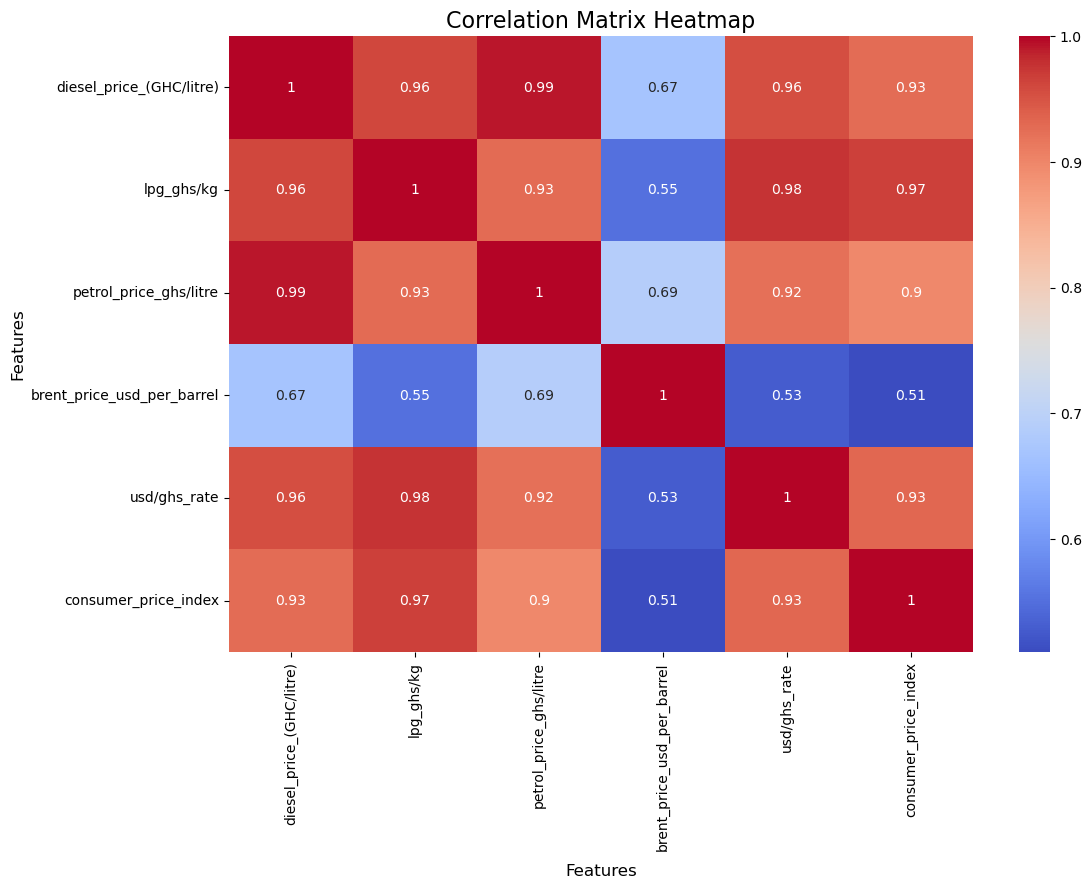

In [18]:
heatmap(df) # plot the correlation matrix as a heatmap

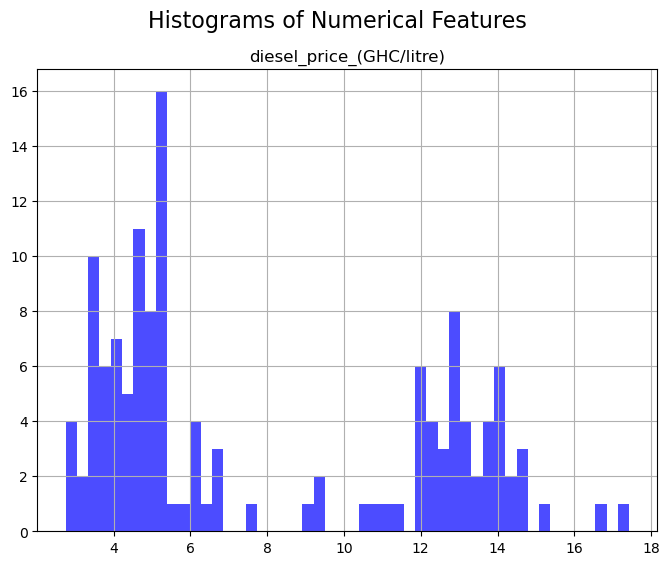

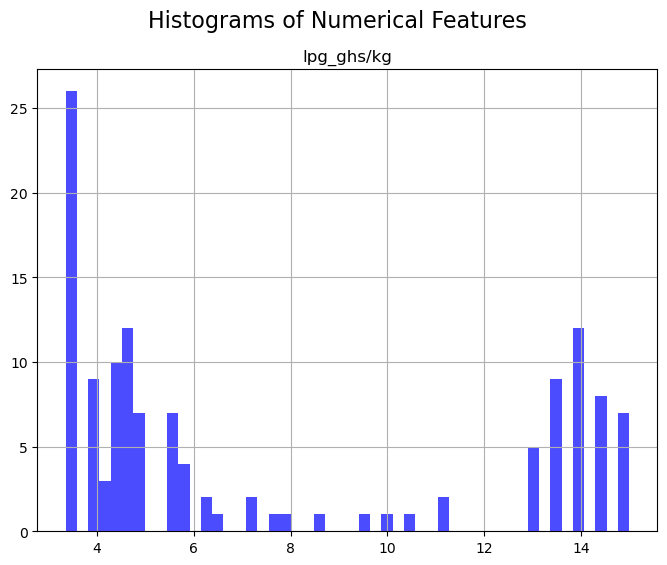

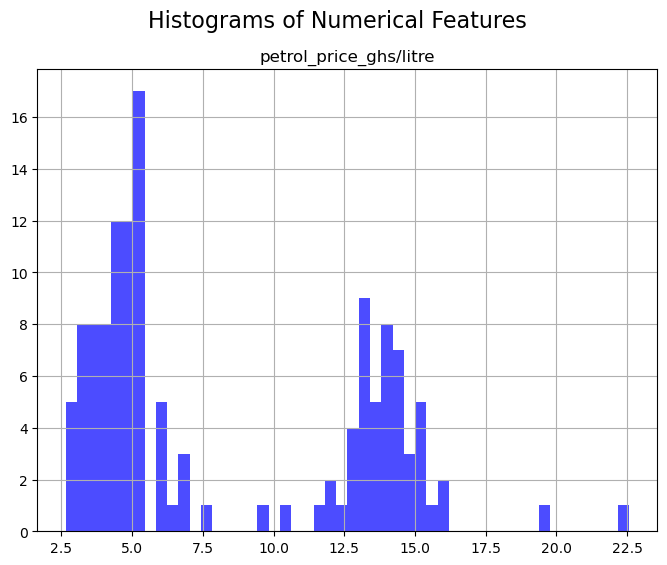

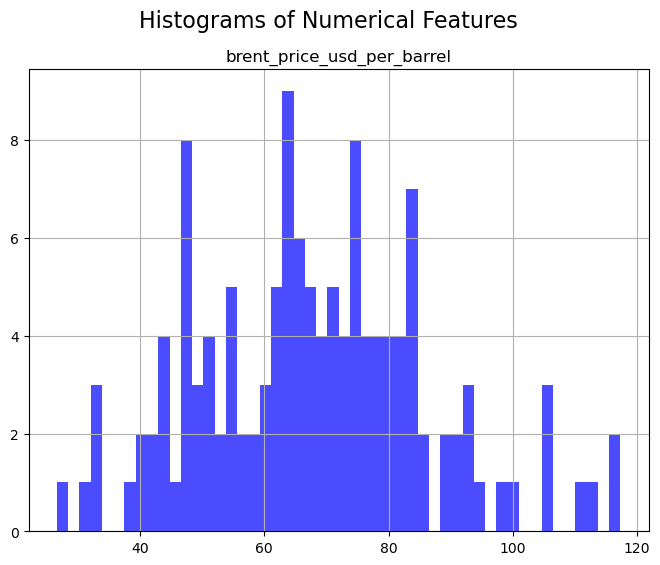

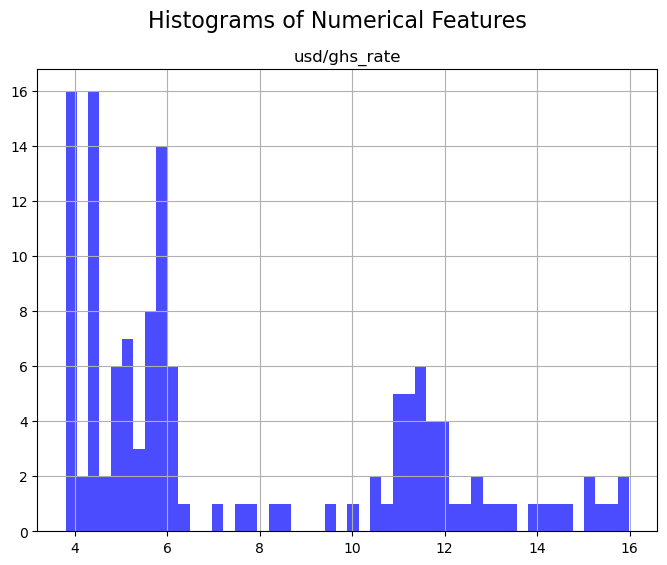

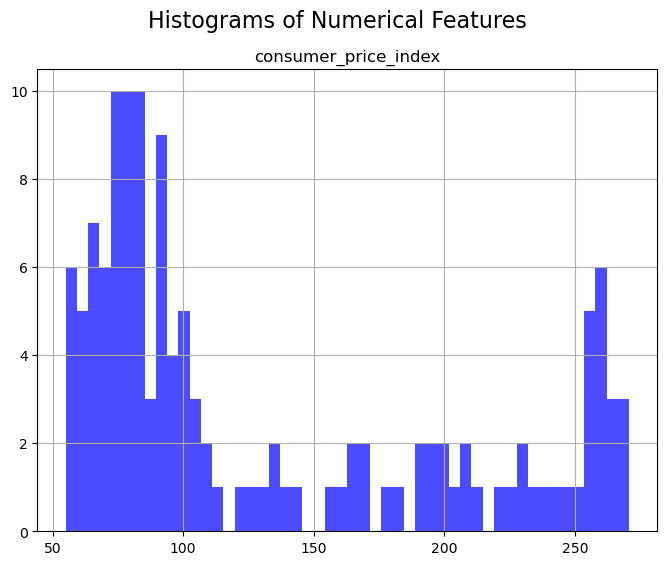

In [25]:
for i in num_cols:
    hist(df[[i]], figsize=(8, 6), bins=50, color='blue', alpha=0.7) # plot the histogram for each numerical column

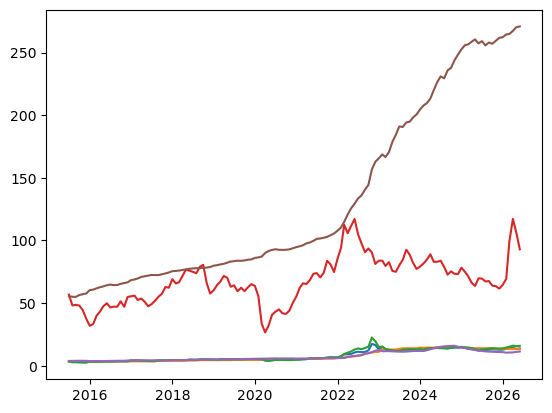

In [20]:
for i in num_cols:
    plt.plot(df.index, df[i])

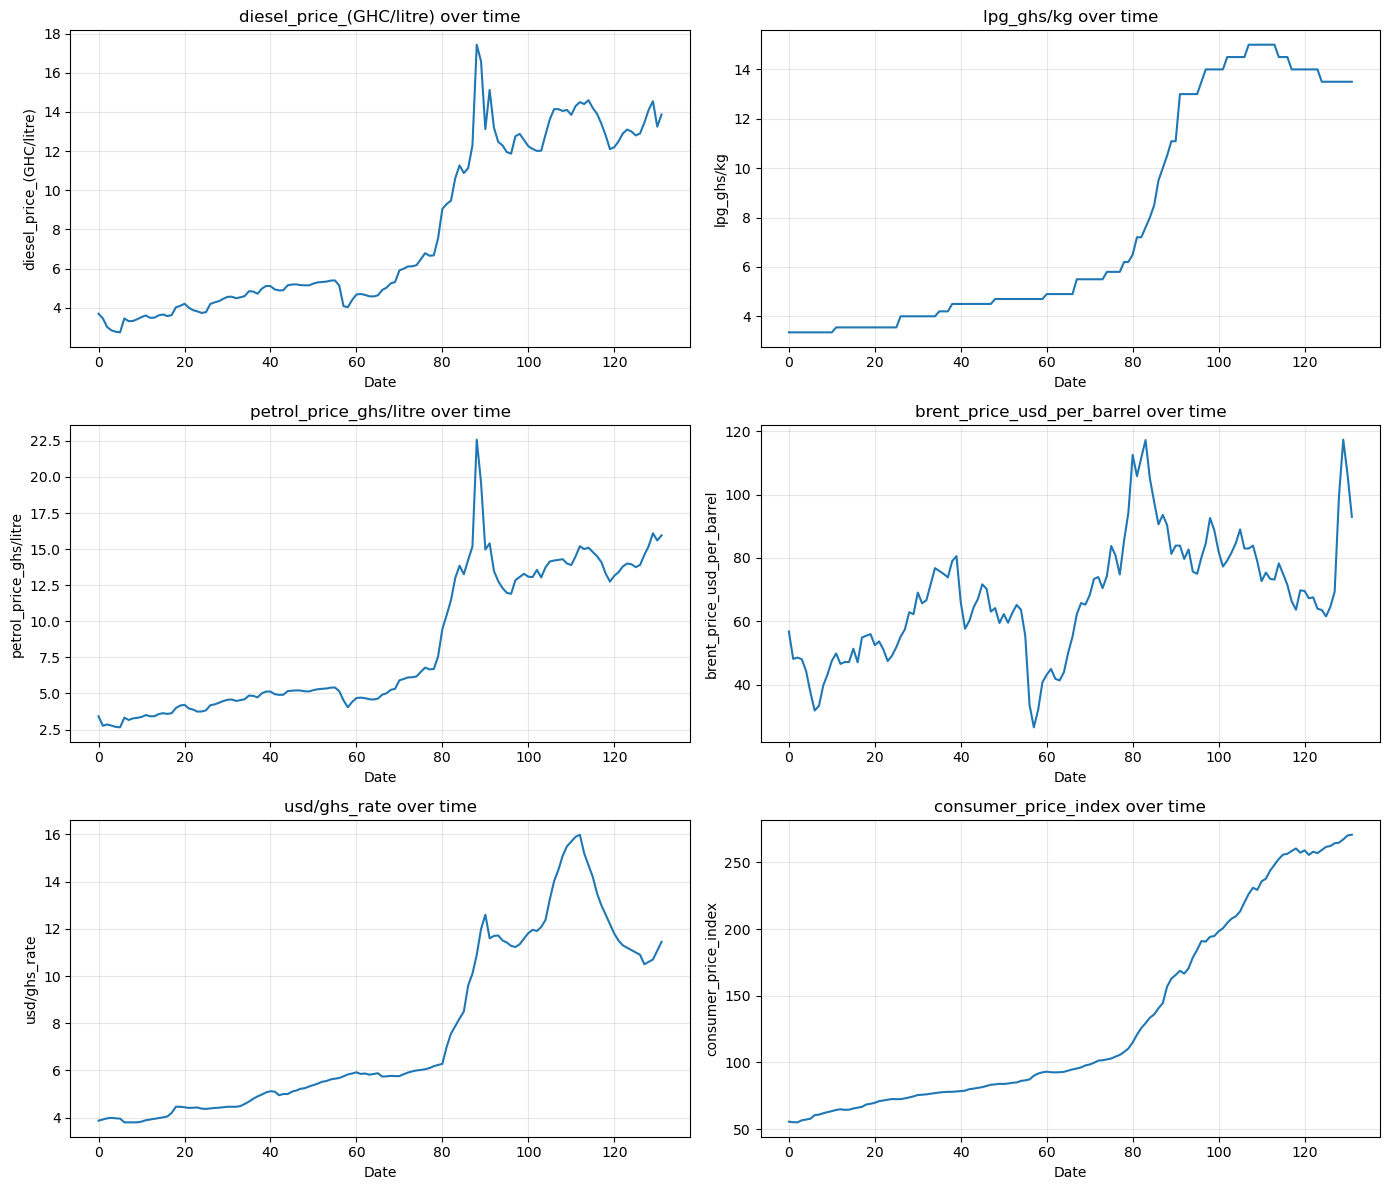

In [33]:
line(df, num_cols)

# plot the line plot for each numerical column

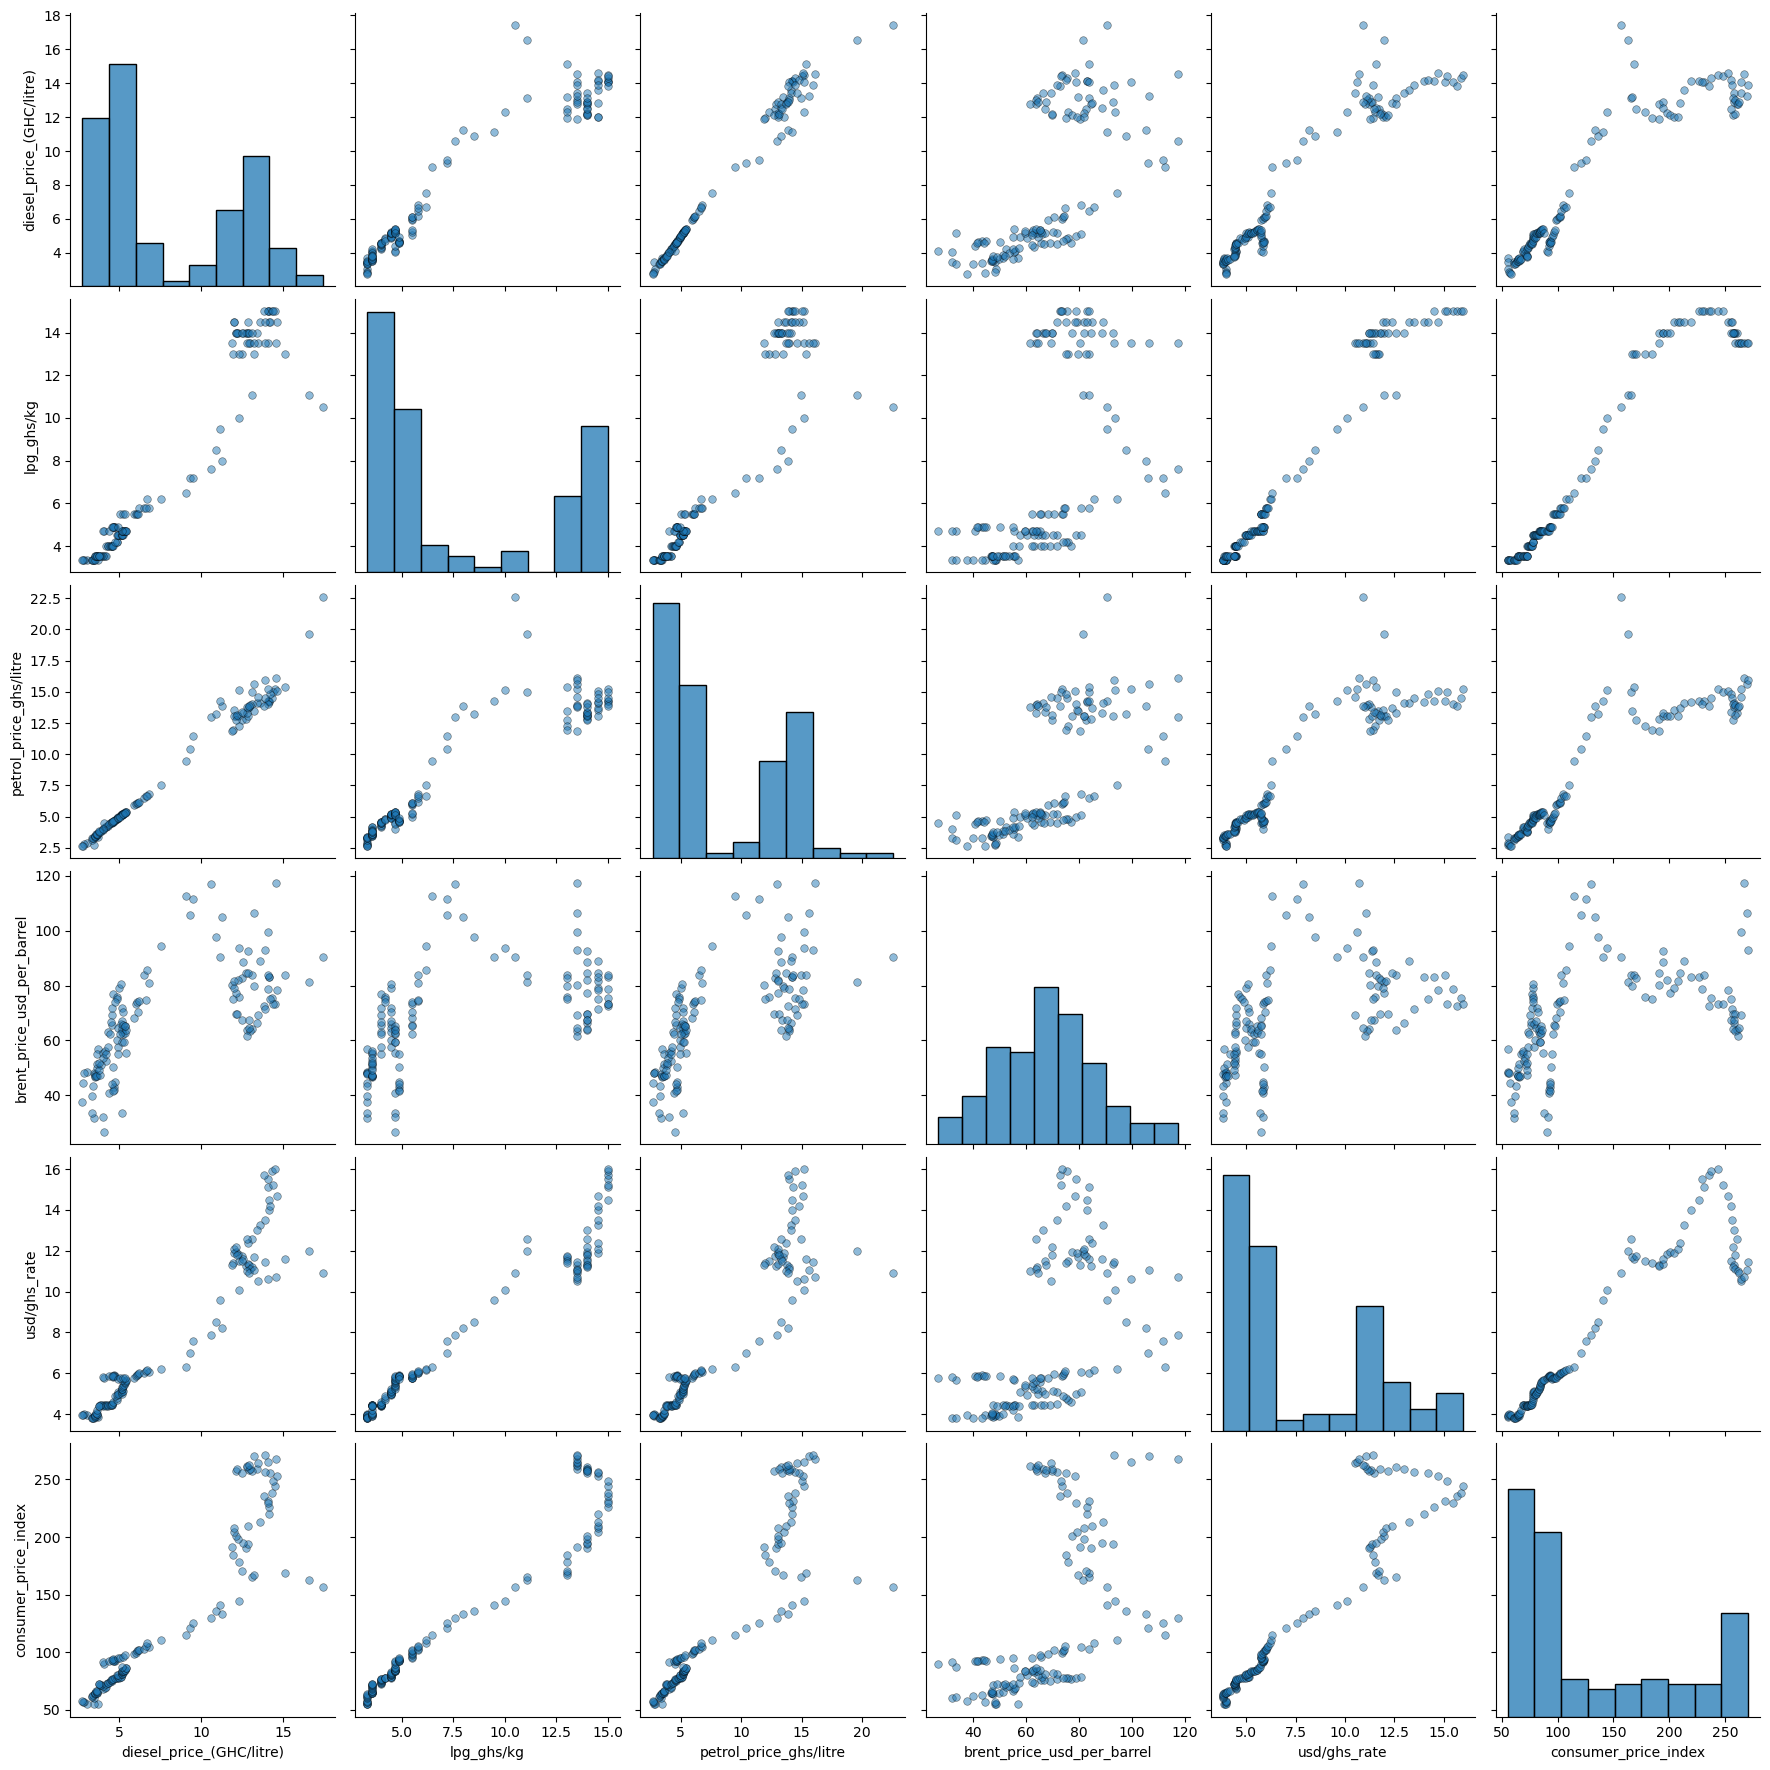

In [ ]:
sns.pairplot(
    df[num_cols], 
    diag_kind='hist', 
    plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'k'}, 
    height=3
    )

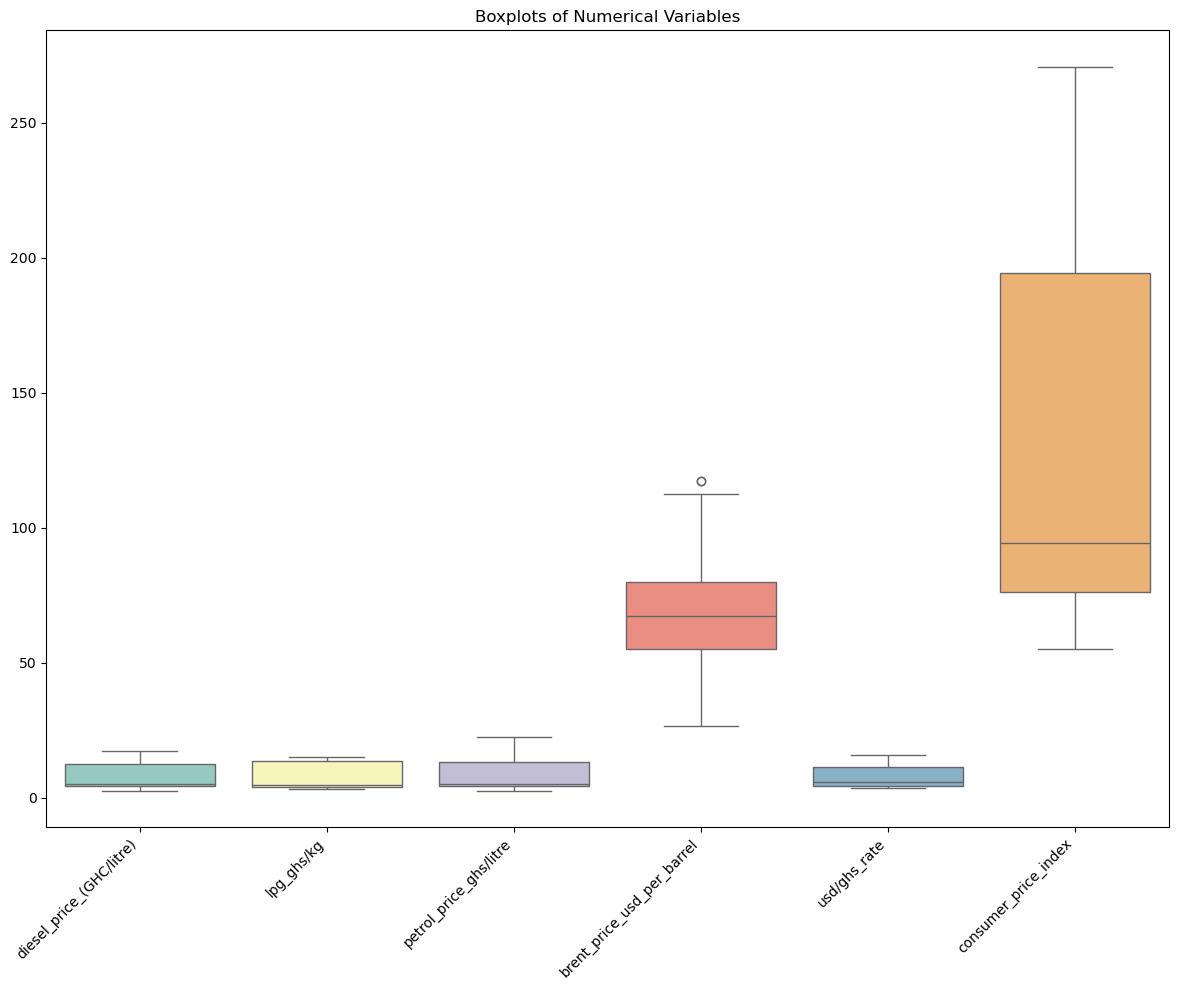

In [ ]:
plt.figure(figsize=(12, 10))

sns.boxplot(
    data=df[num_cols],
    palette="Set3"
)

plt.xticks(rotation=45, ha="right")
plt.title("Boxplots of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
num_cols

Index(['diesel_price_(GHC/litre)', 'lpg_ghs/kg', 'petrol_price_ghs/litre',
       'brent_price_usd_per_barrel', 'usd/ghs_rate', 'consumer_price_index'],
      dtype='object')

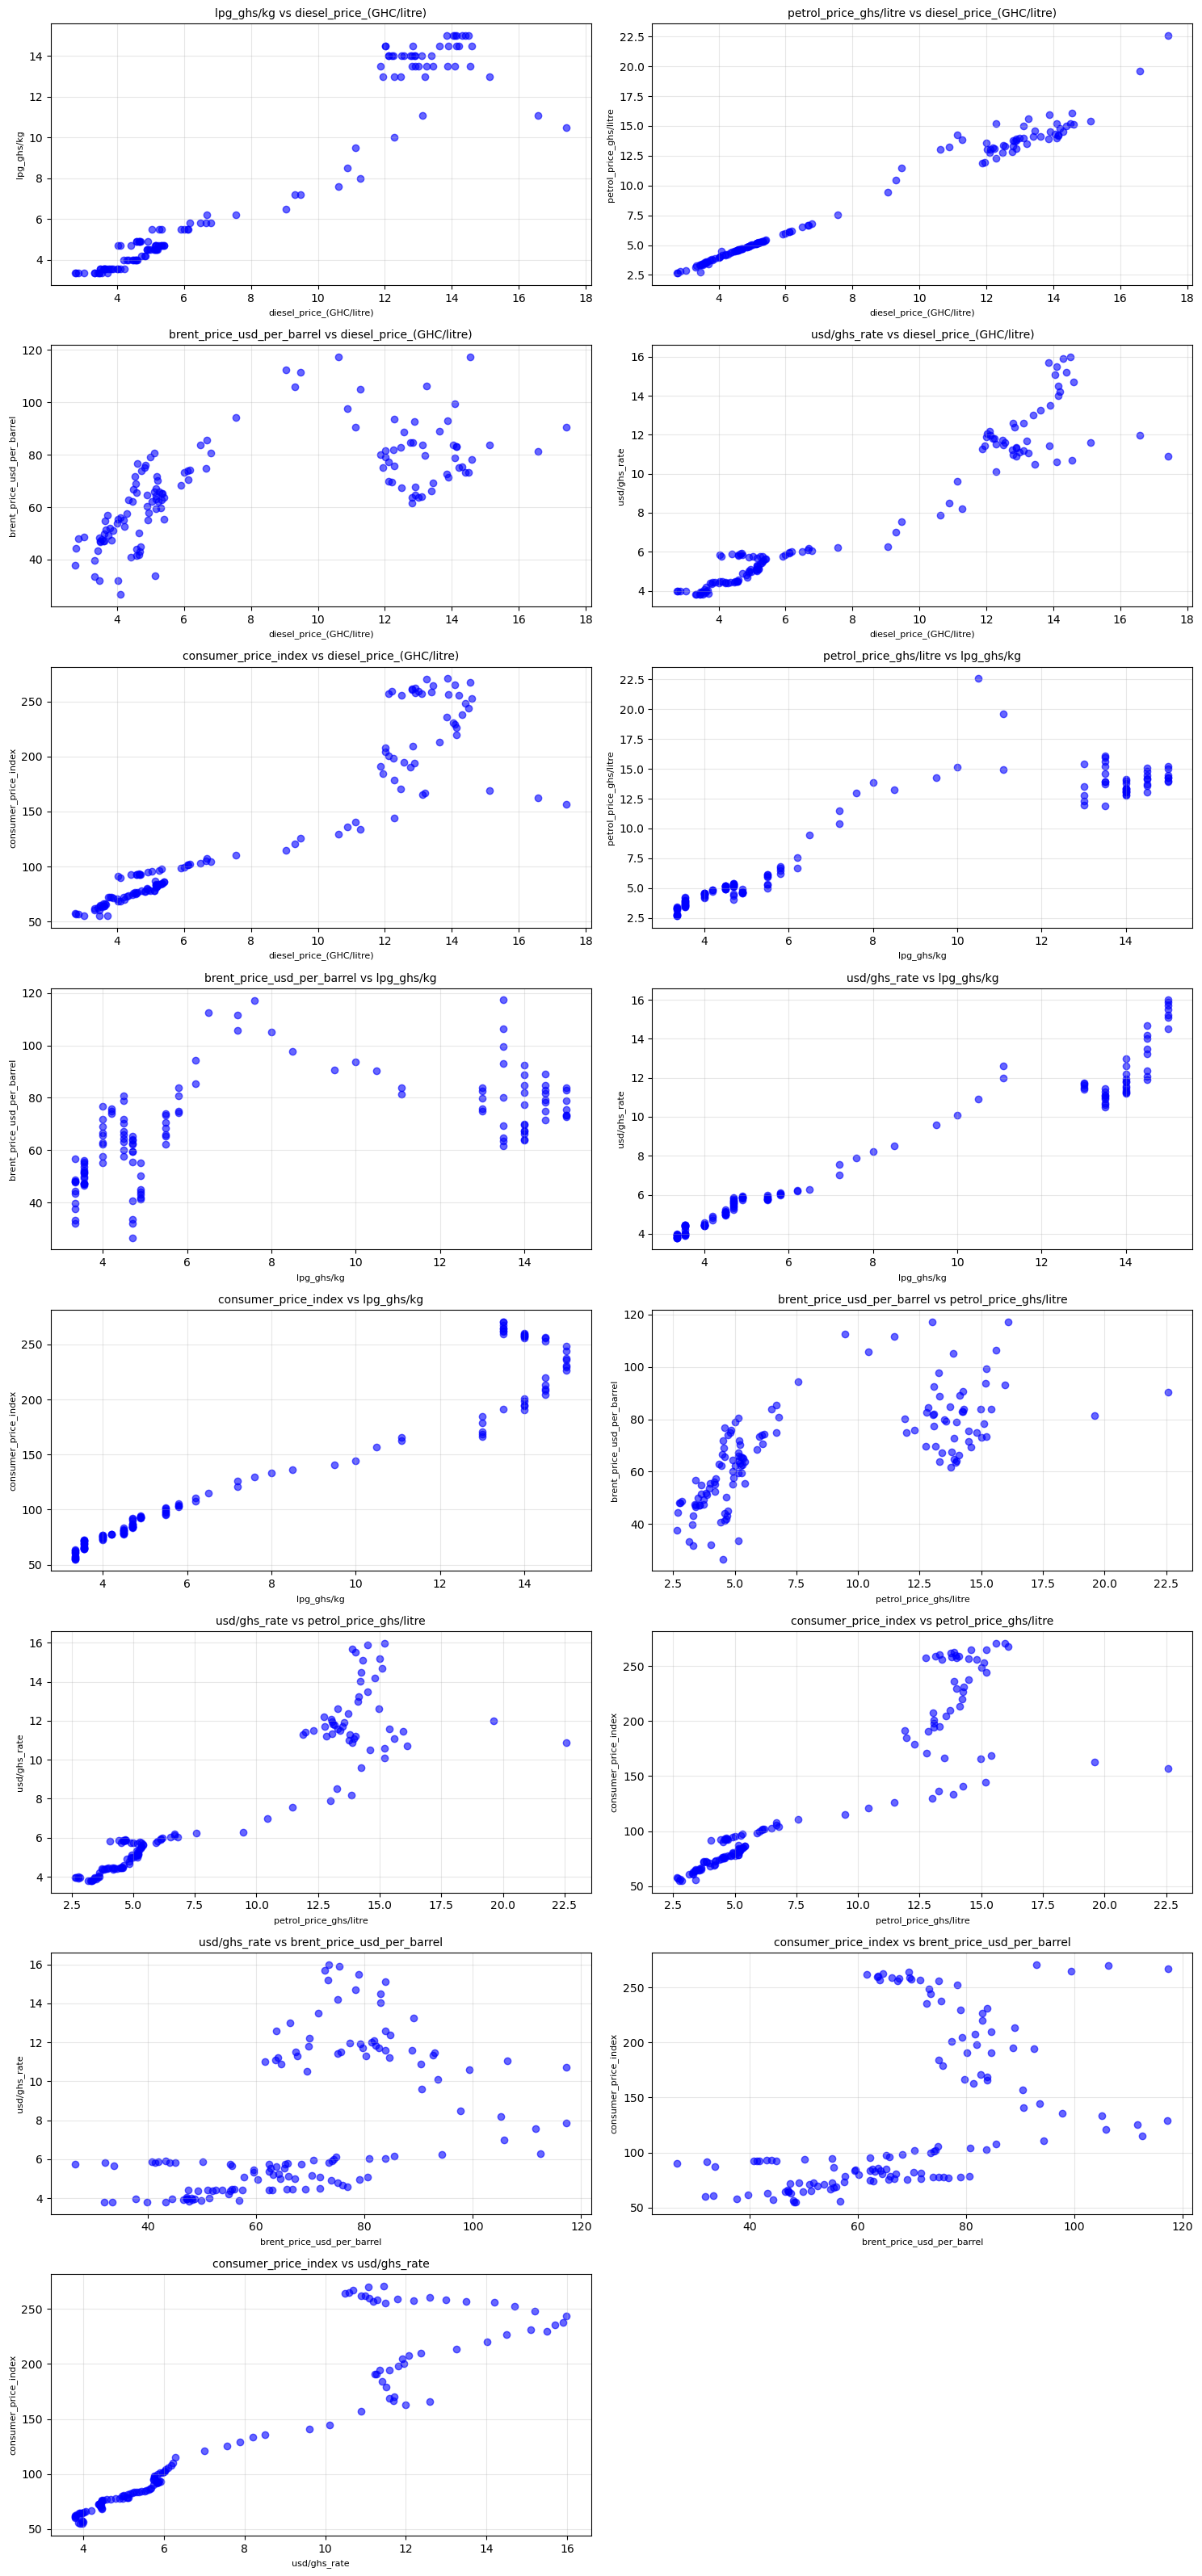

In [ ]:
from itertools import combinations

def scatter_grid(df, num_cols, ncols=2, figsize_width=15, color='blue', alpha=0.6):
    """
    Plots all pairwise scatter plots for the given numeric columns in one grid.
    """
    pairs = list(combinations(num_cols, 2))
    nrows = math.ceil(len(pairs) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_width, 4 * nrows))
    axes = axes.flatten()

    for ax, (x_col, y_col) in zip(axes, pairs):
        ax.scatter(df[x_col], df[y_col], color=color, alpha=alpha)
        ax.set_title(f"{y_col} vs {x_col}", fontsize=10)
        ax.set_xlabel(x_col, fontsize=8)
        ax.set_ylabel(y_col, fontsize=8)
        ax.grid(True, alpha=0.3)

    # remove unused subplot slots
    for ax in axes[len(pairs):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

scatter_grid(df, num_cols)